In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from thermolib.thermodynamics.fep import BaseFreeEnergyProfile, SimpleFreeEnergyProfile, plot_profiles
from thermolib.thermodynamics.histogram import Histogram1D
from thermolib.tools import read_wham_input, decorrelate, plot_histograms_overlap_1d, plot_histograms_1d
from thermolib.thermodynamics.trajectory import ColVarReader

import numpy as np
from molmod.units import *

In [3]:
root = "/home/lvduyfhu/hpc/data_vo/shared/BerndLouis/ethane-multiple-cells/NVT250K-long"
fn_meta = '%s/metadata.dat' %root

In [4]:
colvar_reader = ColVarReader([1], units=['A'])
temp, biasses, trajectories = read_wham_input(
    fn_meta, colvar_reader, '%s', 
    bias_potential='Parabola1D', q01_unit='A', kappa1_unit='kjmol/A**2',
)

<Figure size 640x480 with 0 Axes>

findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.


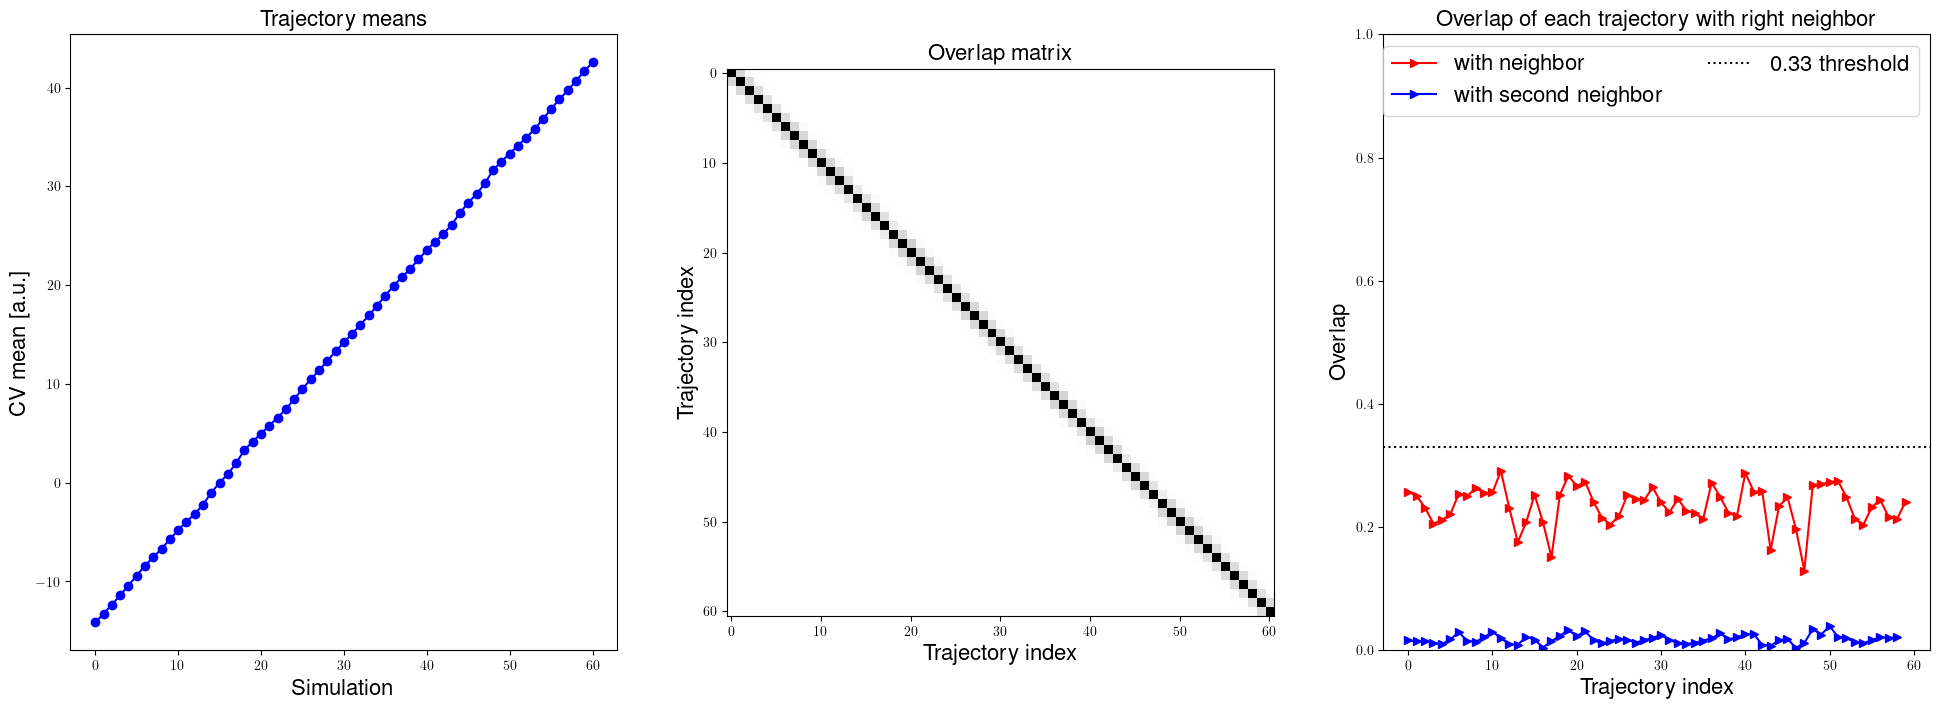

In [5]:
plot_histograms_overlap_1d(trajectories)

<Figure size 640x480 with 0 Axes>

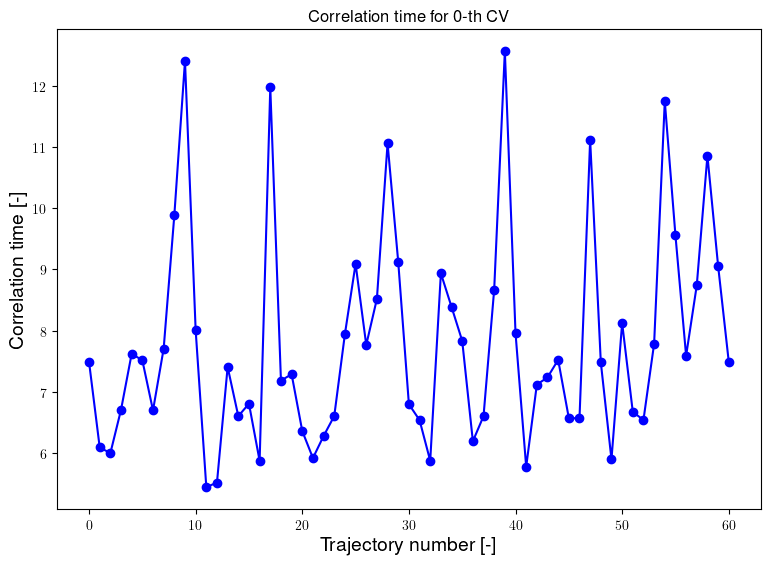

In [6]:
corrtimes = decorrelate(trajectories, plot=True)

In [7]:
bins = np.arange(-8, 23, 0.1)*angstrom

In [8]:
hist = Histogram1D.from_wham(bins, trajectories, biasses, temp, Nscf=10000, error_estimate='mle_f_cov', corrtimes=corrtimes)
fep = SimpleFreeEnergyProfile.from_histogram(hist, temp, cv_output_unit='A', cv_label='CV')
fep.set_ref('min')

SCF did not converge!
---------------------------------------------------------------------
TIMING SUMMARY
  initializing: 00h 00m 00.000s
  histograms  : 00h 00m 00.055s
  bias poten. : 00h 00m 00.005s
  solve scf   : 00h 00m 00.589s
  error est.  : 00h 00m 00.398s
  TOTAL       : 00h 00m 01.048s
---------------------------------------------------------------------


In [9]:
pbc = 0.5*np.sqrt(3)*17.5*angstrom
hist_per = Histogram1D.from_wham(bins, trajectories, biasses, temp, pbc=pbc, Nscf=10000, error_estimate='mle_f_cov', corrtimes=corrtimes)
fep_per = SimpleFreeEnergyProfile.from_histogram(hist_per, temp, cv_output_unit='A', cv_label='CV')
fep_per.set_ref('min')
hist_per2 = Histogram1D.from_wham(bins, trajectories, biasses, temp, pbc=2*pbc, Nscf=10000, error_estimate='mle_f_cov', corrtimes=corrtimes)
fep_per2 = SimpleFreeEnergyProfile.from_histogram(hist_per, temp, cv_output_unit='A', cv_label='CV')
fep_per2.set_ref('min')

SCF Converged!
---------------------------------------------------------------------
TIMING SUMMARY
  initializing: 00h 00m 00.019s
  histograms  : 00h 00m 00.065s
  bias poten. : 00h 00m 00.006s
  solve scf   : 00h 00m 00.048s
  error est.  : 00h 00m 00.288s
  TOTAL       : 00h 00m 00.409s
---------------------------------------------------------------------
SCF Converged!
---------------------------------------------------------------------
TIMING SUMMARY
  initializing: 00h 00m 00.020s
  histograms  : 00h 00m 00.058s
  bias poten. : 00h 00m 00.007s
  solve scf   : 00h 00m 00.142s
  error est.  : 00h 00m 00.454s
  TOTAL       : 00h 00m 00.664s
---------------------------------------------------------------------


<Figure size 640x480 with 0 Axes>

findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.


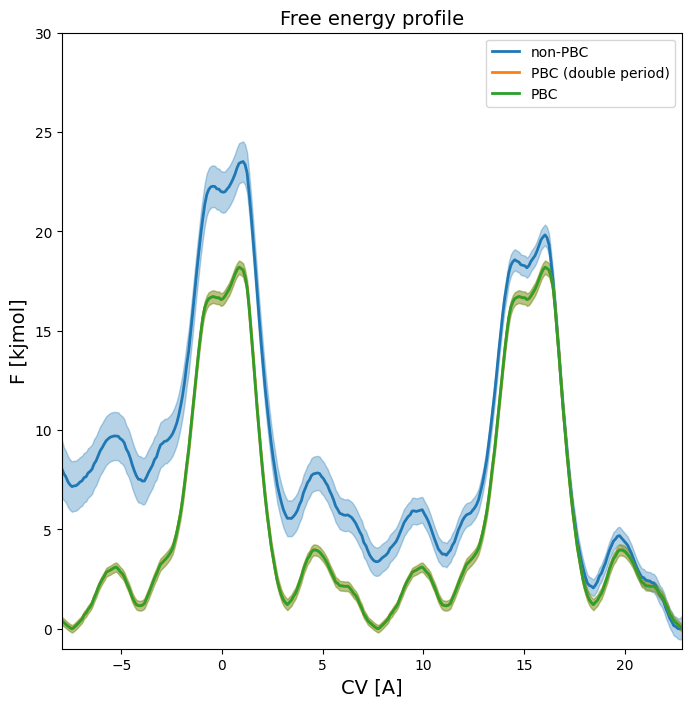

In [10]:
plot_profiles([fep, fep_per2, fep_per], labels=['non-PBC', 'PBC (double period)', 'PBC'])

<Figure size 640x480 with 0 Axes>

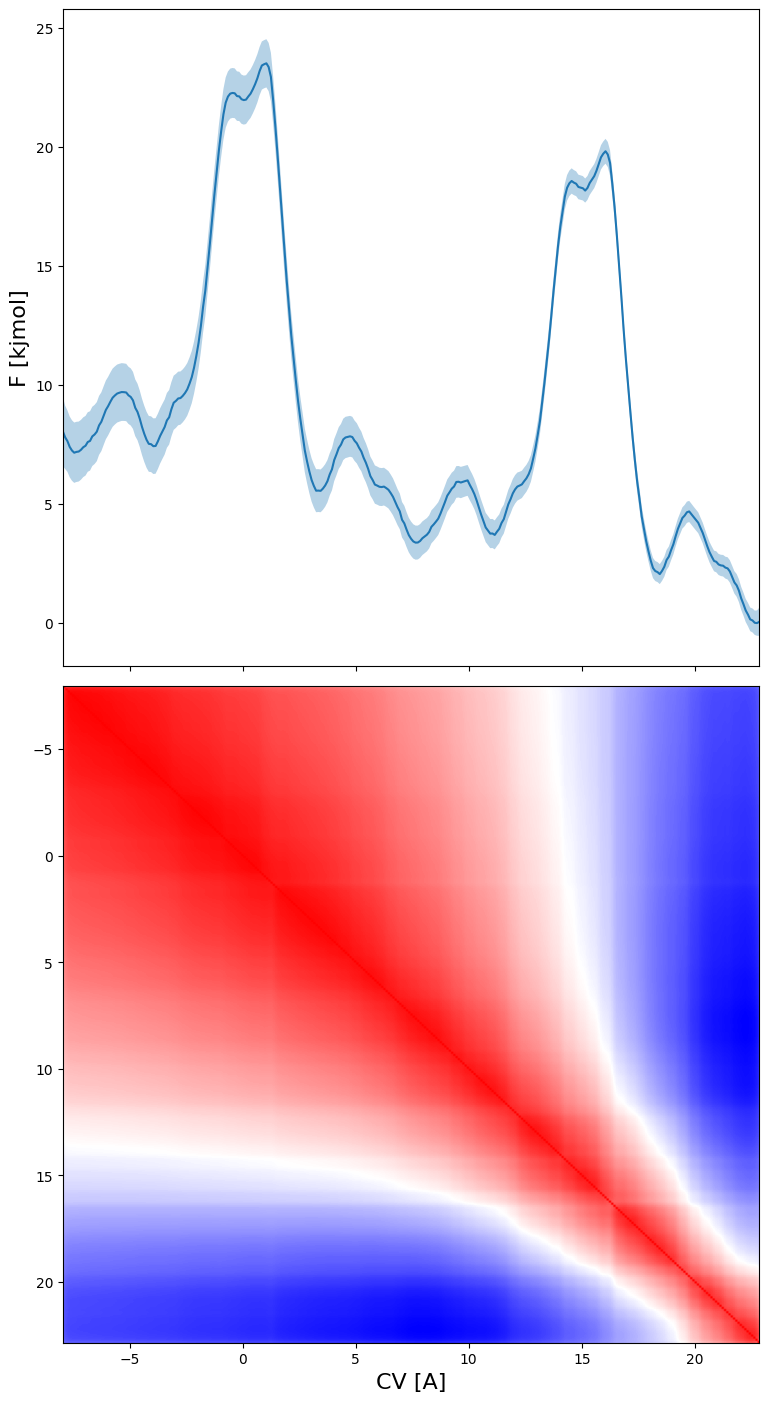

In [11]:
fep.plot_corr_matrix()

<Figure size 640x480 with 0 Axes>

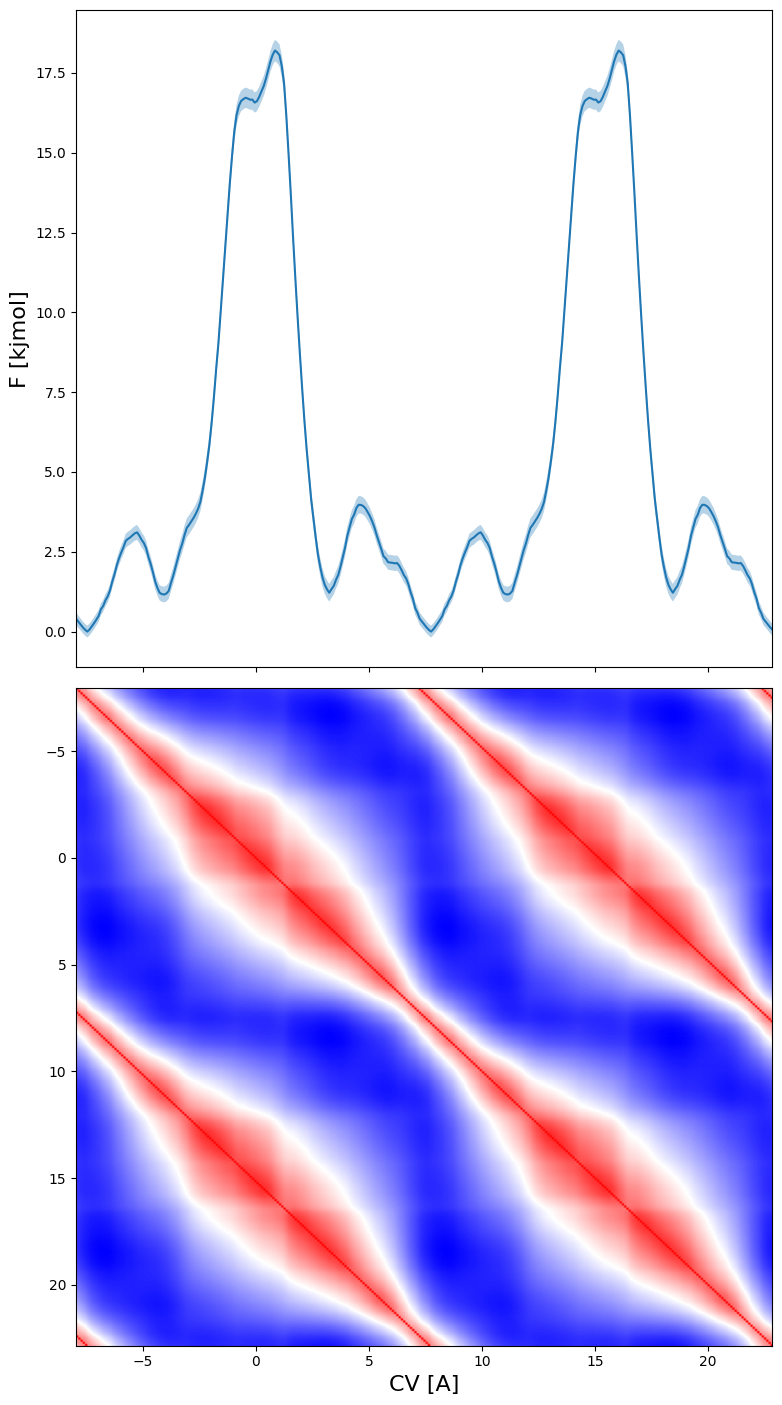

In [12]:
fep_per.plot_corr_matrix()